<a href="https://colab.research.google.com/github/prathik002/DataScience-Lab/blob/main/Program15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
'''Program 15: Dataset: <Breast_Cancer.csv>
a) Conduct exploratory data analysis on the given dataset and report the details.
b) Visualize the analysis results using (i) scatter plot (ii) histogram & (iii) box plot.
c) Implement the Decision Tree algorithm using the dataset and plot the decision tree.'''

# a) Conduct Exploratory Data Analysis (EDA)
import pandas as pd
df = pd.read_csv('/content/Breast-cancer.csv')
print(df.head())
print(df.isnull().sum())
print(df.describe())
print(df['radius_mean'].value_counts())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

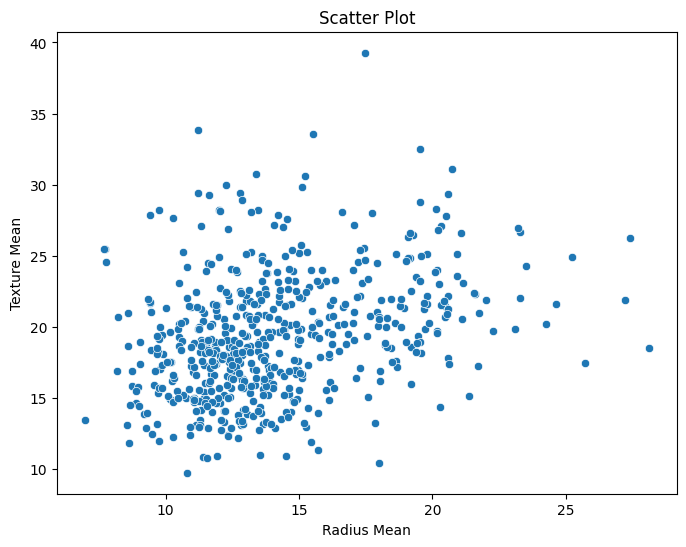

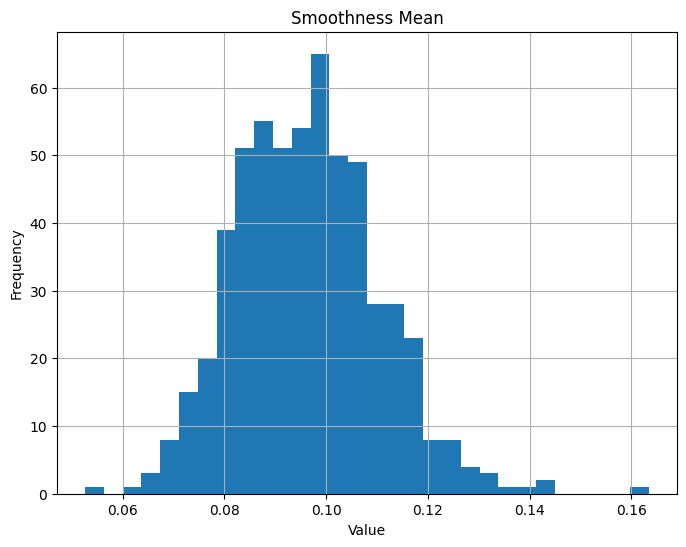

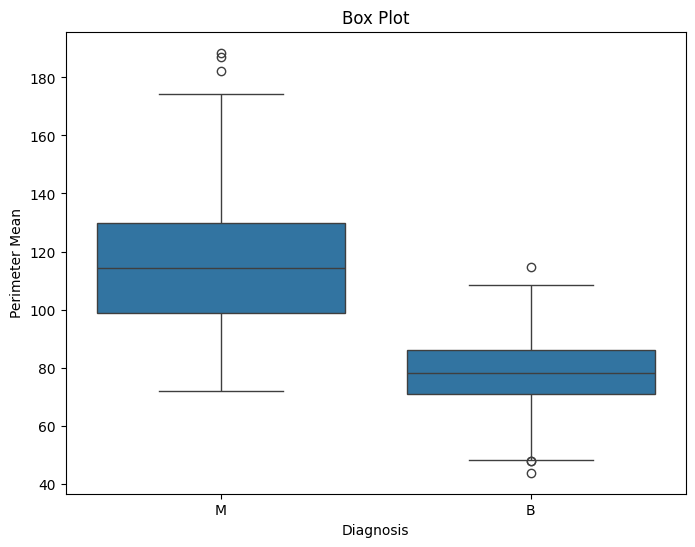

In [6]:
#b) Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

#(i) Scatter Plot
plt.figure(figsize=(8,6))
sns.scatterplot(x='radius_mean', y='texture_mean', data=df)
plt.title('Scatter Plot')
plt.xlabel('Radius Mean')
plt.ylabel('Texture Mean')
plt.show()

#(ii) Histogram
plt.figure(figsize=(8,6))
df['smoothness_mean'].hist(bins=30)
plt.title('Smoothness Mean')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

#(iii) Box Plot
plt.figure(figsize=(8,6))
sns.boxplot(x='diagnosis', y='perimeter_mean', data=df)
plt.title('Box Plot')
plt.xlabel('Diagnosis')
plt.ylabel('Perimeter Mean')
plt.show()

Accuracy: 0.956140350877193
Accuracy (%): 95.6140350877193

Classification Report:
              precision    recall  f1-score   support

           B       0.95      0.99      0.97        72
           M       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



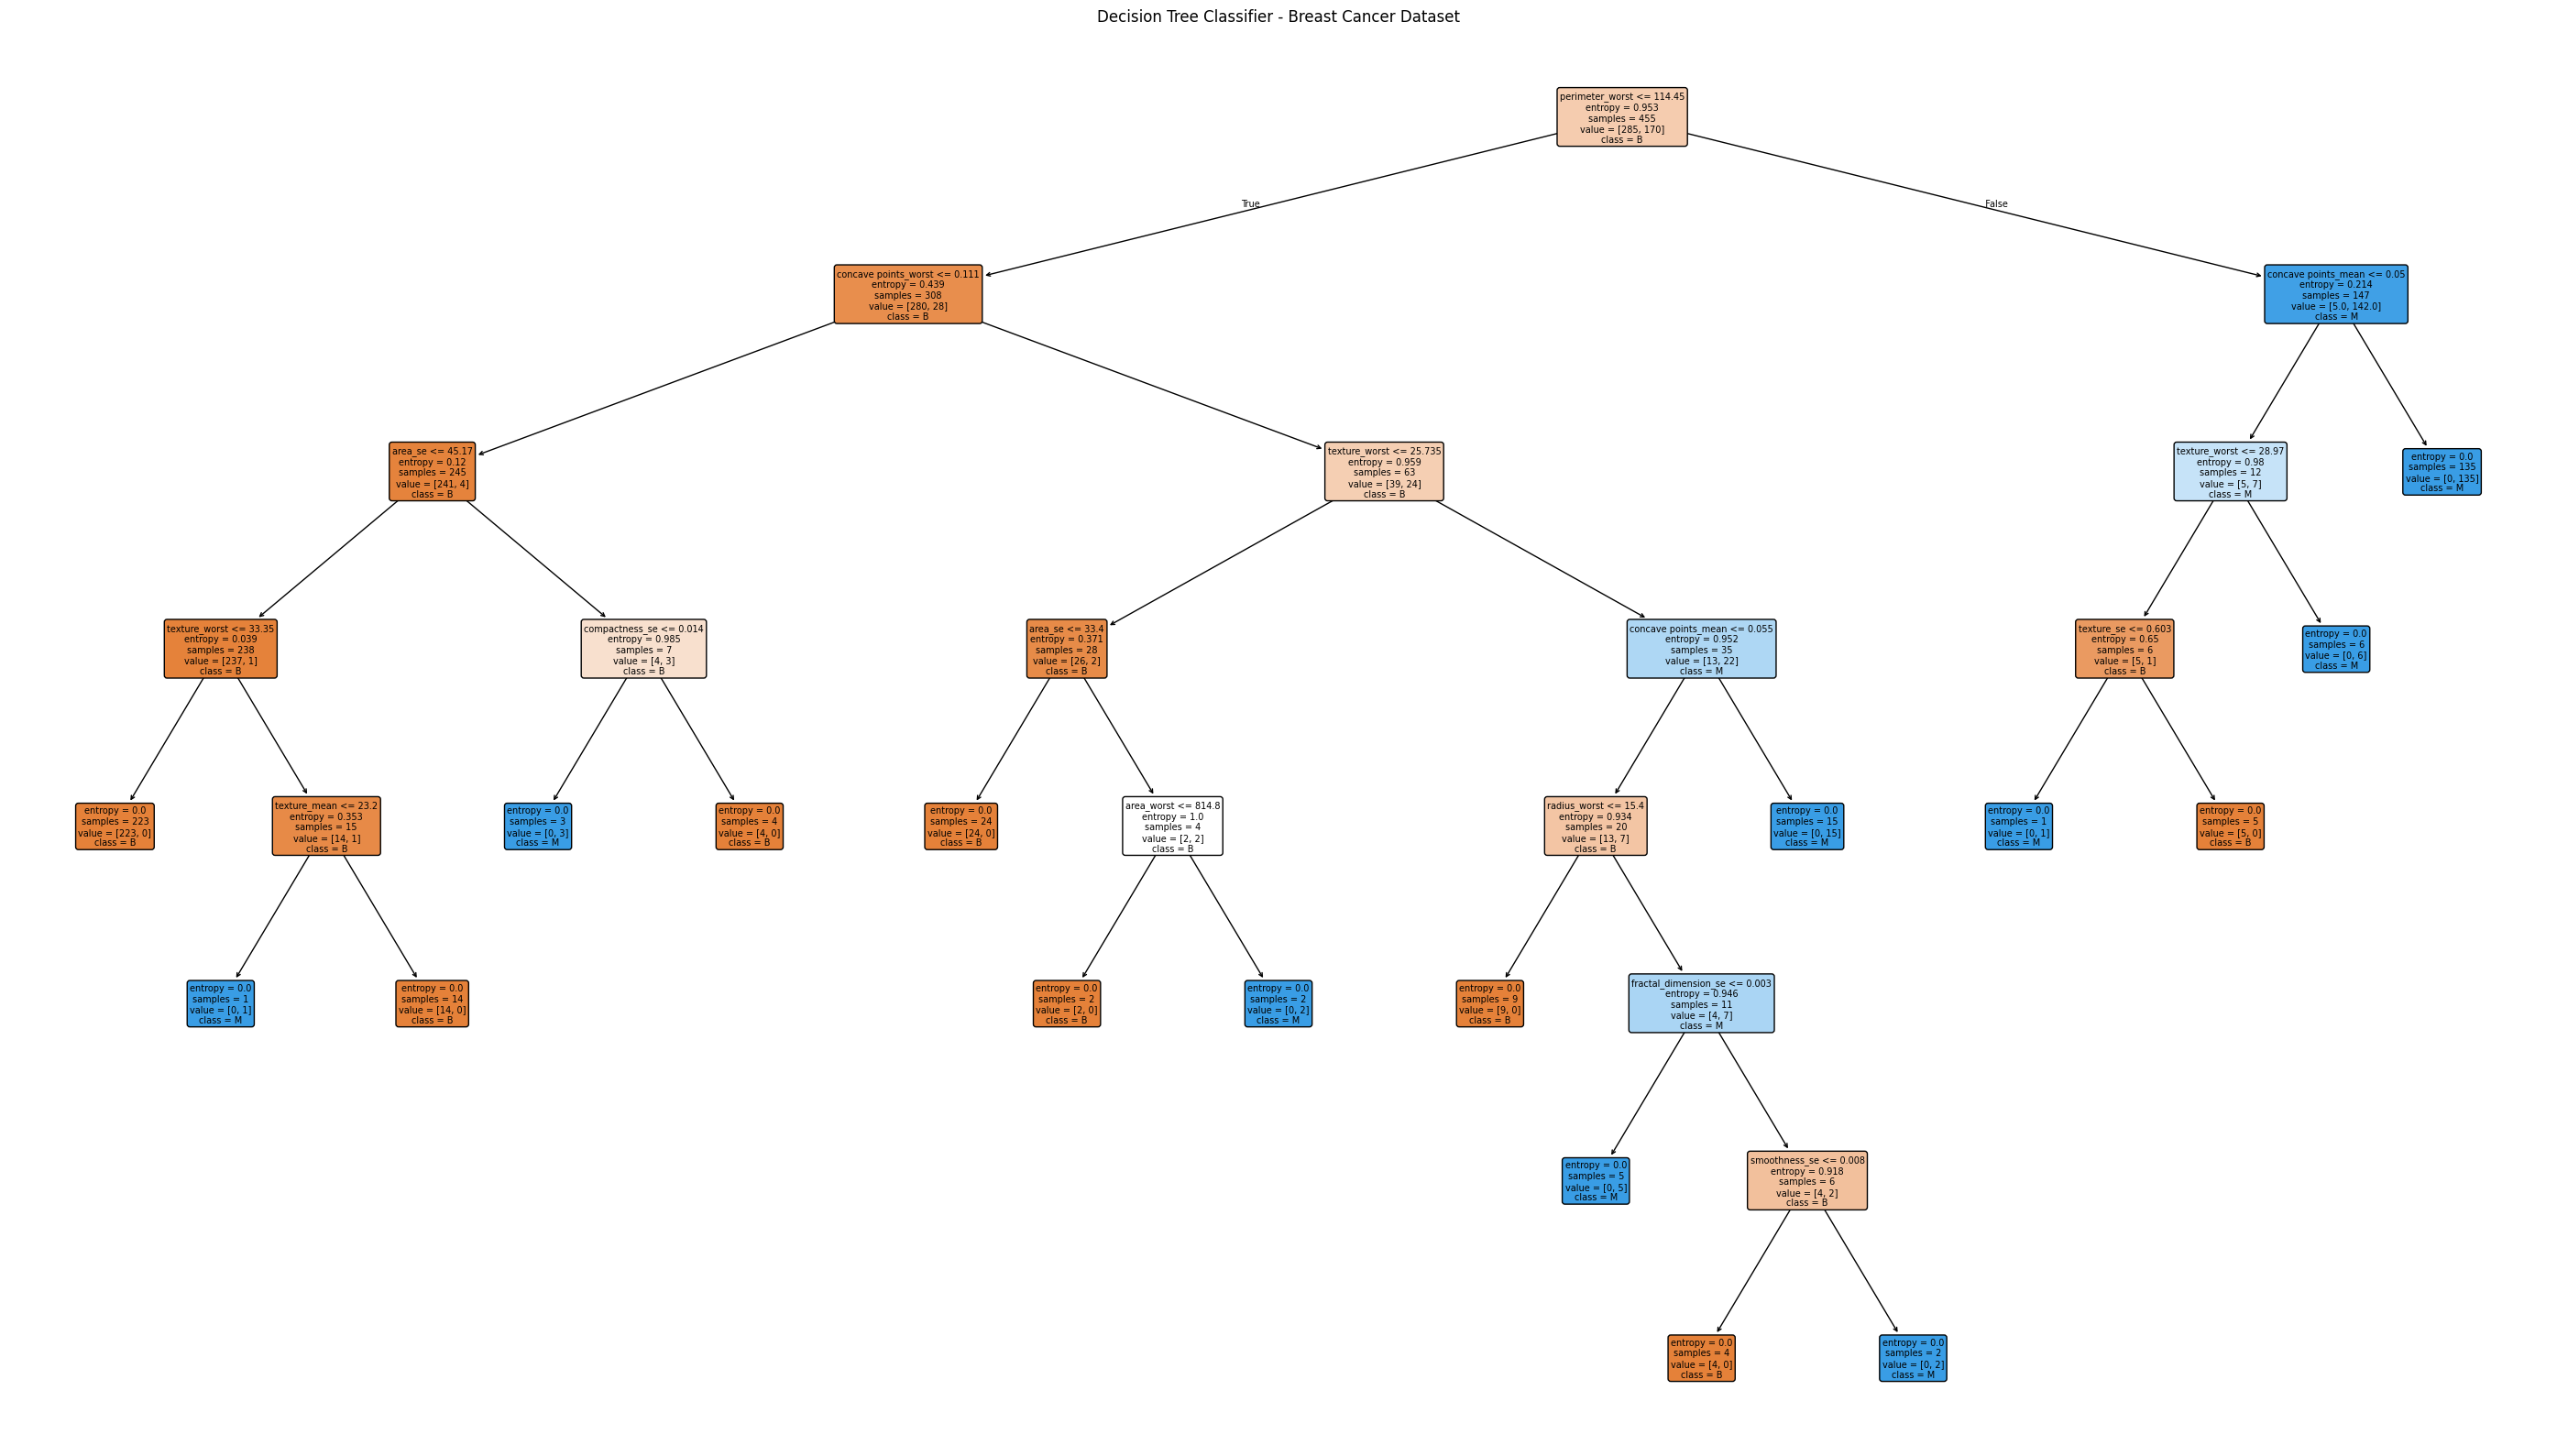

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
df = pd.read_csv("/content/Breast-cancer.csv")

# Remove unnecessary columns
df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")

# Features and target
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# Encode target: B = 0, M = 1
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create Decision Tree
dt = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

# Train model
dt.fit(X_train, y_train)

# Predict
y_pred = dt.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

# Plot Decision Tree
plt.figure(figsize=(28, 16))

plot_tree(
    dt,
    feature_names=X.columns,
    class_names=encoder.classes_,
    filled=True,
    rounded=True,
    fontsize=7
)

plt.title("Decision Tree Classifier - Breast Cancer Dataset")
plt.tight_layout()
plt.show()